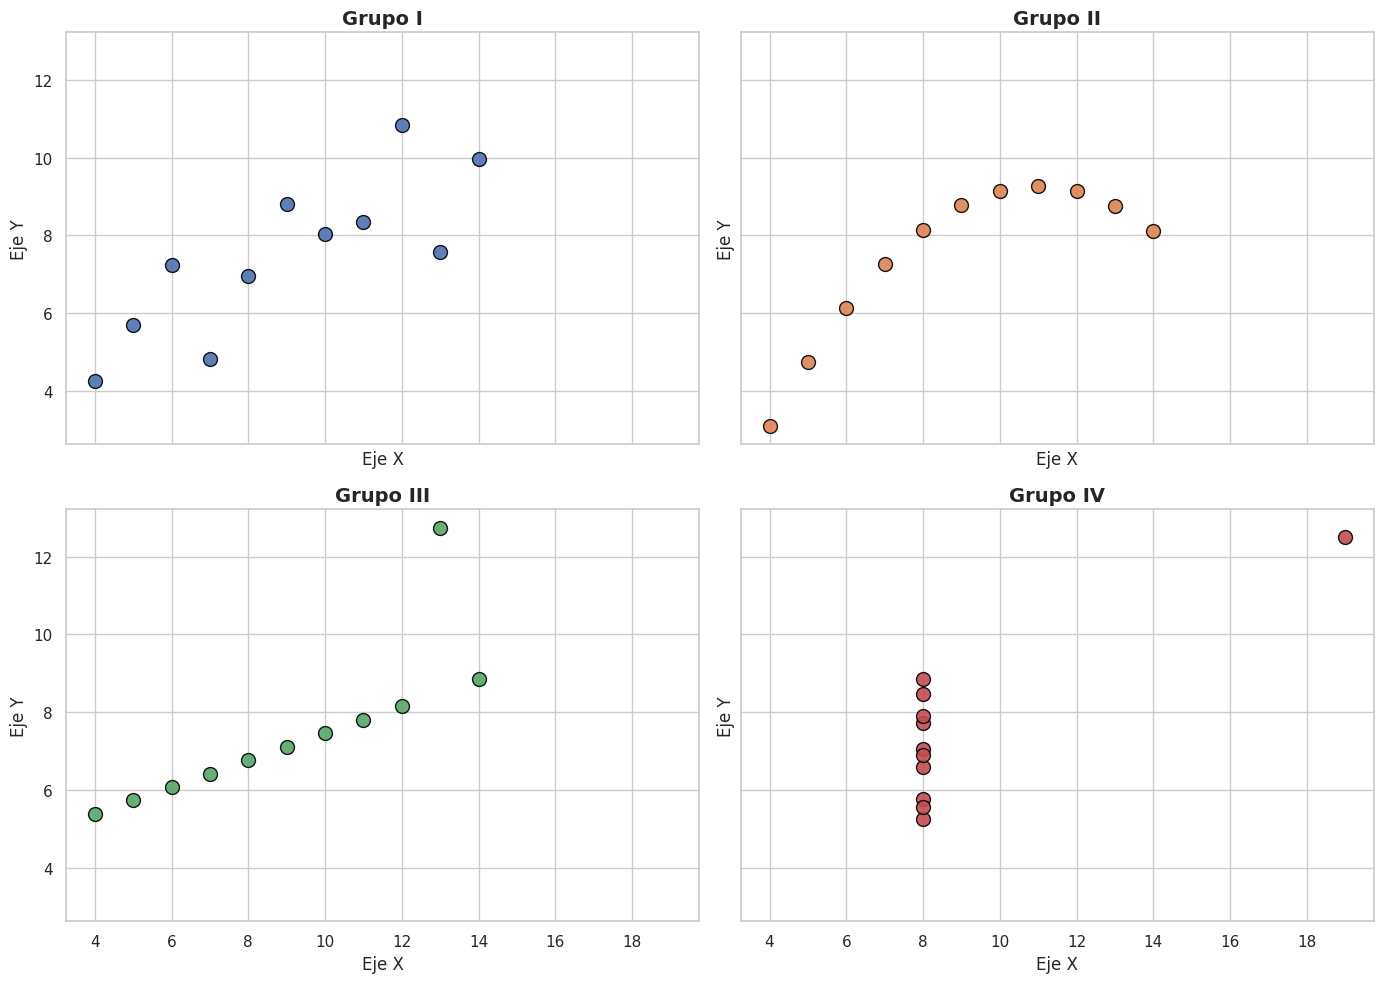

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Forzar la carga limpia de los datos y configuración de estilo
sns.set_theme(style="whitegrid")
data = sns.load_dataset("anscombe")

# 2. Crear la figura con 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Aplanar la matriz para iterar fácilmente

grupos = ['I', 'II', 'III', 'IV']
colores = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']  # Un color único por grupo

# 3. Dibujar cada grupo de forma explícita
for i, grupo in enumerate(grupos):
    # Filtrar el grupo correspondiente de manera segura
    df_grupo = data[data['dataset'] == grupo]

    # Graficar los puntos
    axes[i].scatter(df_grupo['x'], df_grupo['y'], color=colores[i], s=100, alpha=0.9, edgecolor='black')

    # Configurar títulos y etiquetas
    axes[i].set_title(f"Grupo {grupo}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Eje X")
    axes[i].set_ylabel("Eje Y")

# Ajustar los espacios entre los gráficos
plt.tight_layout()
plt.show()

In [4]:
print("=== RESUMEN ESTADÍSTICO DE LOS 4 GRUPOS ===")
# Agrupamos por dataset y transponemos la tabla (.T) para que sea mucho más fácil de leer en pantalla
display(data.groupby("dataset").describe().T)

=== RESUMEN ESTADÍSTICO DE LOS 4 GRUPOS ===


dataset          I         II        III         IV
x count  11.000000  11.000000  11.000000  11.000000
  mean    9.000000   9.000000   9.000000   9.000000
  std     3.316625   3.316625   3.316625   3.316625
  min     4.000000   4.000000   4.000000   8.000000
  25%     6.500000   6.500000   6.500000   8.000000
  50%     9.000000   9.000000   9.000000   8.000000
  75%    11.500000  11.500000  11.500000   8.000000
  max    14.000000  14.000000  14.000000  19.000000
y count  11.000000  11.000000  11.000000  11.000000
  mean    7.500909   7.500909   7.500000   7.500909
  std     2.031568   2.031657   2.030424   2.030579
  min     4.260000   3.100000   5.390000   5.250000
  25%     6.315000   6.695000   6.250000   6.170000
  50%     7.580000   8.140000   7.110000   7.040000
  75%     8.570000   8.950000   7.980000   8.190000
  max    10.840000   9.260000  12.740000  12.500000

 Al mirar el resultado en tu notebook notarás algo sorprendente: la media de $X$ es 9.0 en todos, la media de $Y$ es 7.50 en todos, y las desviaciones estándar son idénticas. Esto demuestra que la estadística descriptiva tradicional es ciega ante la forma real de los datos, reforzando la importancia de graficar.

Grupo I -> MSE: 1.251 | R²: 0.667 | Pendiente: 0.50
Grupo II -> MSE: 1.252 | R²: 0.666 | Pendiente: 0.50
Grupo III -> MSE: 1.251 | R²: 0.666 | Pendiente: 0.50
Grupo IV -> MSE: 1.249 | R²: 0.667 | Pendiente: 0.50


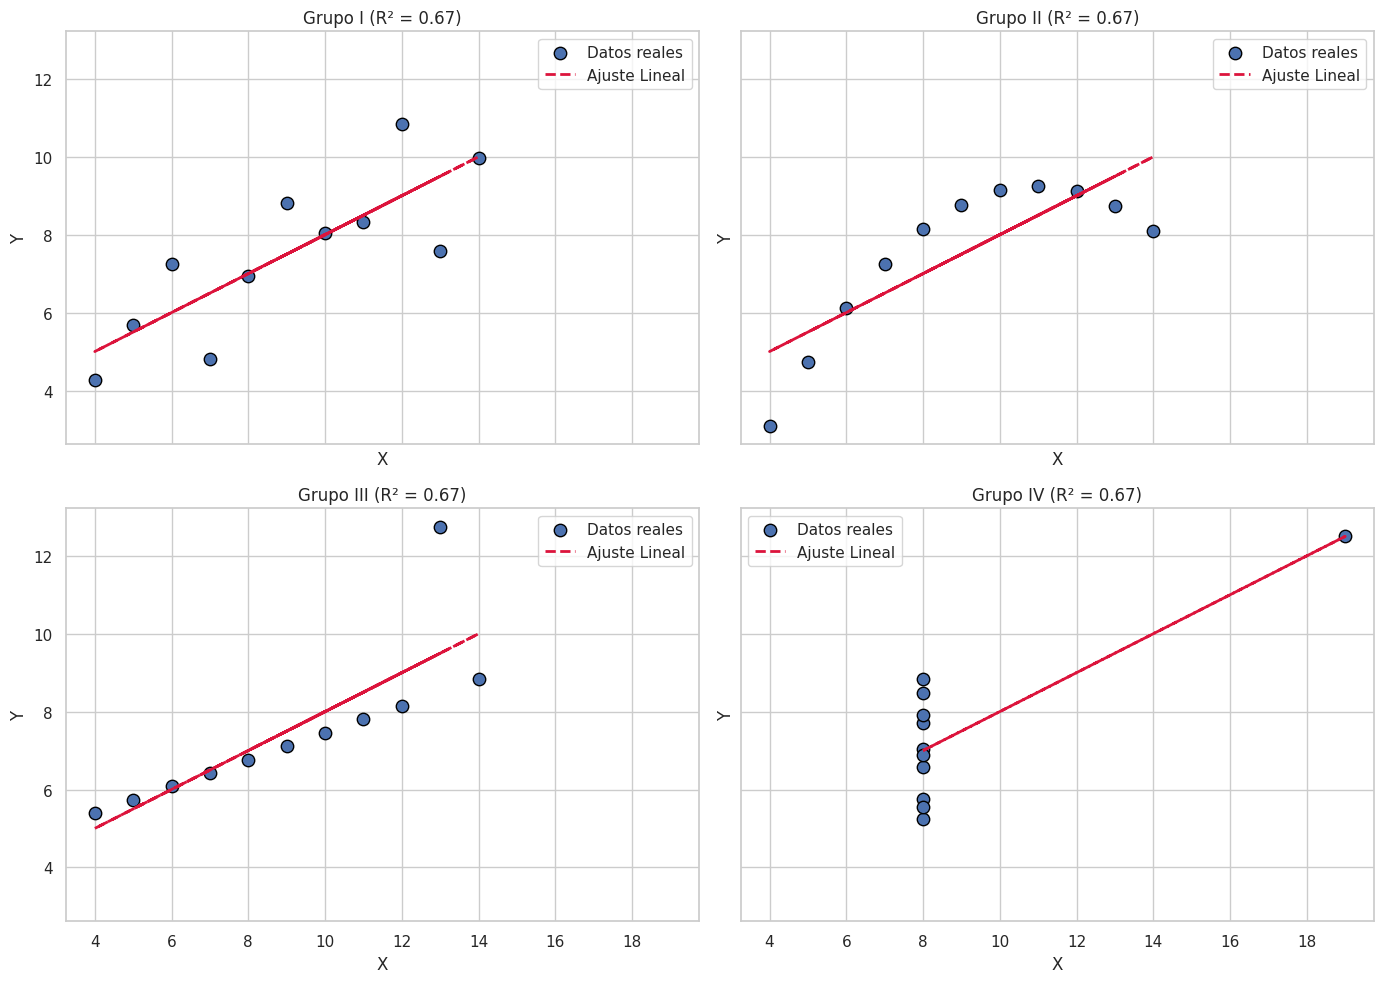

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

grupos = ['I', 'II', 'III', 'IV']

for i, grupo in enumerate(grupos):
    # 1. Filtrar datos por grupo
    df_grupo = data[data['dataset'] == grupo]
    X = df_grupo[['x']].values
    y = df_grupo['y'].values

    # 2. Entrenar el modelo lineal
    model = LinearRegression()
    model.fit(X, y)

    # 3. Predecir y calcular métricas
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Imprimir resumen de métricas en la consola
    print(f"Grupo {grupo} -> MSE: {mse:.3f} | R²: {r2:.3f} | Pendiente: {model.coef_[0]:.2f}")

    # 4. Graficar los puntos reales y la línea de regresión estimada
    axes[i].scatter(X, y, color='#4c72b0', s=80, label='Datos reales', edgecolor='black')
    axes[i].plot(X, y_pred, color='crimson', linestyle='--', linewidth=2, label='Ajuste Lineal')
    axes[i].set_title(f"Grupo {grupo} (R² = {r2:.2f})")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    axes[i].legend()

plt.tight_layout()
plt.show()

Numéricamente, el $R^2$ ($\approx 0.67$) y el $MSE$ ($\approx 1.25$) son exactamente iguales en los 4 casos. Sin embargo, el impacto visual demuestra que el ajuste lineal es un fracaso para la mayoría: en el Grupo II ignora la curvatura, en el Grupo III la recta es arrastrada hacia arriba por culpa de un único outlier, y en el Grupo IV la línea se sostiene de forma artificial gracias a un punto aislado.

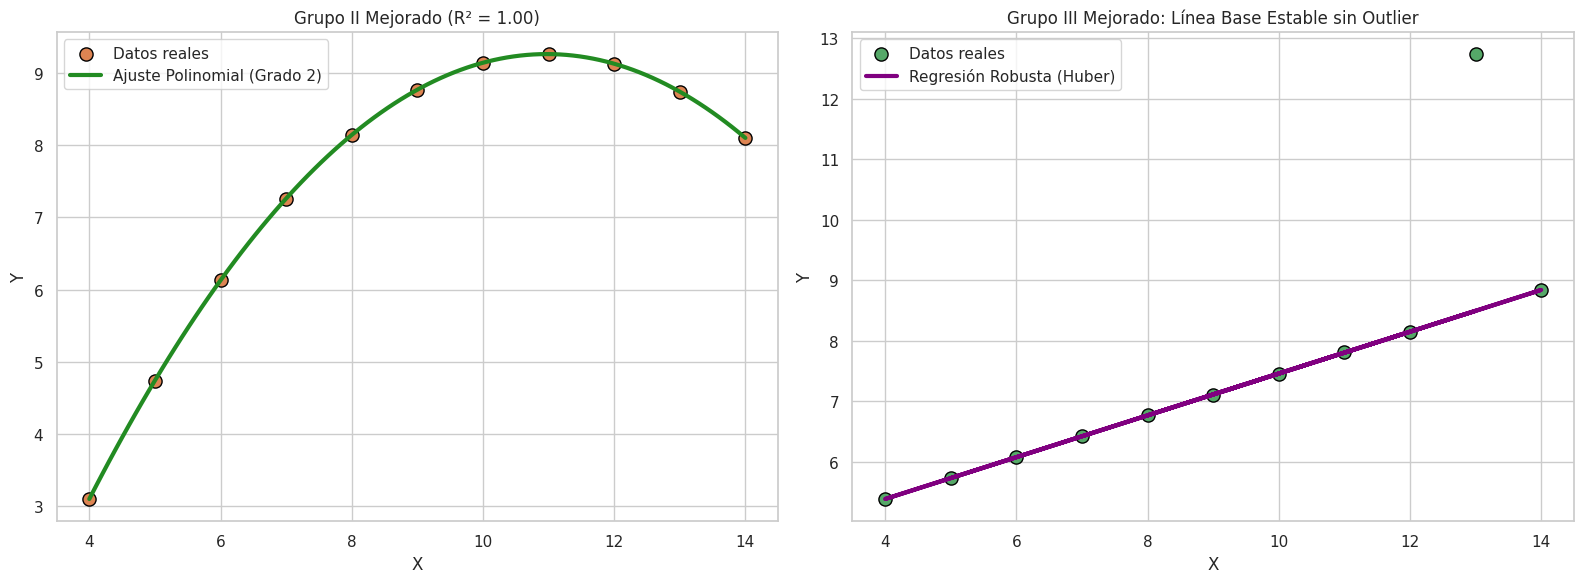

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import HuberRegressor

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Estrategia Grupo II: Regresión Polinomial (Curva) ---
df_ii = data[data['dataset'] == 'II']
X_ii = df_ii[['x']].values
y_ii = df_ii['y'].values

# Transformamos X para agregar el término cuadrático (x²)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_ii)

model_poly = LinearRegression()
model_poly.fit(X_poly, y_ii)

# Creamos una línea suave para pintar la curva perfecta
X_smooth = np.linspace(X_ii.min(), X_ii.max(), 100).reshape(-1, 1)
y_smooth = model_poly.predict(poly.transform(X_smooth))

ax1.scatter(X_ii, y_ii, color='#dd8452', s=90, edgecolor='black', label='Datos reales')
ax1.plot(X_smooth, y_smooth, color='forestgreen', linewidth=3, label='Ajuste Polinomial (Grado 2)')
ax1.set_title(f"Grupo II Mejorado (R² = {r2_score(y_ii, model_poly.predict(X_poly)):.2f})")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend()

# --- Estrategia Grupo III: Regresión Robusta (Huber) contra Outliers ---
df_iii = data[data['dataset'] == 'III']
X_iii = df_iii[['x']].values
y_iii = df_iii['y'].values

# El modelo Huber detecta y despondera automáticamente los puntos atípicos
model_robust = HuberRegressor()
model_robust.fit(X_iii, y_iii)

ax2.scatter(X_iii, y_iii, color='#55a868', s=90, edgecolor='black', label='Datos reales')
ax2.plot(X_iii, model_robust.predict(X_iii), color='purple', linewidth=3, label='Regresión Robusta (Huber)')
ax2.set_title("Grupo III Mejorado: Línea Base Estable sin Outlier")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.legend()

plt.tight_layout()
plt.show()